In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Load the iris dataset
iris = load_iris()

In [3]:
# Create a DataFrame for easy manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [4]:
print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Dataset loaded successfully. Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
# Drop duplicate rows if any exist (Iris typically has 1 duplicate row)
initial_shape = df.shape
df.drop_duplicates(inplace=True)
final_shape = df.shape
print(f"Removed {initial_shape[0] - final_shape[0]} duplicate row(s).")
print(f"New dataset shape: {final_shape}")

Removed 1 duplicate row(s).
New dataset shape: (149, 5)


In [6]:
# Separate features (X) and drop the target to prevent feature leakage
X = df.drop(columns=['target'])

In [7]:
# Scale the 4D features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
print("Features separated and scaled successfully.")
print("Sample scaled row:\n", X_scaled[0])

Features separated and scaled successfully.
Sample scaled row:
 [-0.8980334   1.01240113 -1.33325507 -1.30862368]


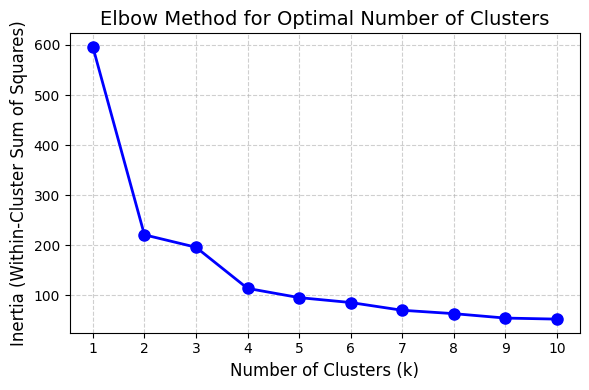

In [21]:
# Compute inertia (Within-Cluster Sum of Squares) for different values of k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
# Initialize and fit K-Means with 3 clusters and a fixed random state for reproducibility
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

In [10]:
# Add the resulting cluster labels back to the dataframe for tracking
df['Cluster'] = cluster_labels

In [11]:
# Calculate Silhouette Score using the original scaled 4D features
sil_avg = silhouette_score(X_scaled, cluster_labels)

In [12]:
print(f"K-Means clustering complete for k = 3.")
print(f"Average Silhouette Score (calculated on 4D scaled data): {sil_avg:.4f}")

K-Means clustering complete for k = 3.
Average Silhouette Score (calculated on 4D scaled data): 0.4939


In [13]:
# Reduce dimensions from 4D to 2D for visualization purposes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [14]:
# Store PCA coordinates back into the dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
print("PCA dimensionality reduction complete.")
df[['PCA1', 'PCA2', 'Cluster']].head()

PCA dimensionality reduction complete.


,PCA1,PCA2,Cluster
0,-2.252692,0.479299,1
1,-2.071004,-0.674234,1
2,-2.353147,-0.340442,1
3,-2.288762,-0.595441,1
4,-2.377294,0.646885,1


In [15]:
# Define colors for the 3 distinct clusters
colors = {0: 'red', 1: 'blue', 2: 'green'}
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

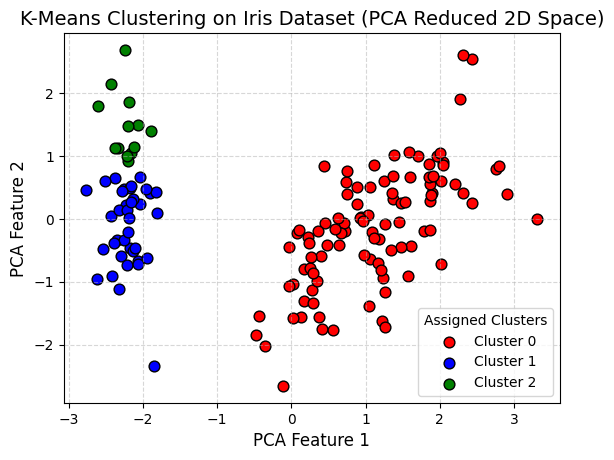

In [16]:
# Plot each cluster group
for cluster_id, color in colors.items():
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['PCA1'],
        cluster_data['PCA2'],
        c=color,
        label=f'Cluster {cluster_id}',
        edgecolors='k',
        s=60
    )
plt.title('K-Means Clustering on Iris Dataset (PCA Reduced 2D Space)', fontsize=14)
plt.xlabel('PCA Feature 1', fontsize=12)
plt.ylabel('PCA Feature 2', fontsize=12)
plt.legend(title="Assigned Clusters")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()